# NBAIoT — ML Classification (Universal)

**Dataset:** [N-BaIoT on Kaggle](https://www.kaggle.com/datasets/mkashifn/nbaiot-dataset)  
**Задача 1:** Бинарная классификация — benign vs malicious  
**Задача 2:** Мультиклассовая — определение типа атаки  

---
### Как настроить ноутбук
Все параметры — в ячейке **«Конфигурация»**:
| Параметр | Что меняет |
|---|---|
| `SAMPLE_FRACTION` | Доля датасета (0.0–1.0). `0.1` = 10%, `1.0` = весь датасет |
| `TEST_SIZE` | Доля тестовой выборки от отобранного объёма |
| `N_TOP_FEATURES` | Число топ-признаков по корреляции с целевой переменной |
| `MODELS` | Словарь алгоритмов — добавляйте/удаляйте без изменения остального кода |

## 0. Конфигурация железа

In [31]:
import platform, subprocess
import psutil

print("=" * 62)
print("КОНФИГУРАЦИЯ СИСТЕМЫ")
print("=" * 62)
print(f"Процессор         : {platform.processor()}")

print(f"Ядра CPU (физ.)   : {psutil.cpu_count(logical=False)}")
print(f"Ядра CPU (лог.)   : {psutil.cpu_count(logical=True)}")


ram = psutil.virtual_memory()
print(f"RAM всего         : {ram.total / 1024**3:.2f} ГБ")
print(f"RAM доступно      : {ram.available / 1024**3:.2f} ГБ")

КОНФИГУРАЦИЯ СИСТЕМЫ
Процессор         : x86_64
Ядра CPU (физ.)   : 16
Ядра CPU (лог.)   : 32
RAM всего         : 251.89 ГБ
RAM доступно      : 232.40 ГБ


## 1. Импорты и конфигурация

In [61]:
import time, warnings, gc, copy
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path
from sklearn.base import clone
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, RobustScaler, StandardScaler
from sklearn.decomposition import PCA
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    classification_report, confusion_matrix, ConfusionMatrixDisplay
)

# Путь к директории с CSV-файлами датасета
DATA_DIR = Path("../datasets")

# Доли датасета, задействованные в обучении и тестах. Диапазон: (0.0, 1.0]
SAMPLE_FRACTIONS = [0.05, 0.1, 0.25, 0.5, 1.0]

# Одиночное значение для метрик в секциях 10–14
SAMPLE_FRACTION = 0.5

# Количества ядер, задействованные в обучении и тестах
N_JOBS_LIST = [1, 2, 4, 8, 16, 32]

# Одиночное значение для cpu-замеров в секциях 10–14
CORES_SAMPLE_FRACTION = 1.0


# Доля тестовой выборки от отобранных данных
TEST_SIZE = 0.20

# Кол-во топ-признаков по корреляции с целевой переменной (бинарная задача)
N_TOP_FEATURES = 15

RANDOM_STATE = 42
METRICS = ["accuracy", "precision", "recall"]

sns.set_theme(style="whitegrid", palette="muted")
print(f"Конфигурация ноутбука:")
print(f"SAMPLE_FRACTIONS  = {SAMPLE_FRACTIONS}")
print(f"(финальный прогон: {SAMPLE_FRACTION*100:.0f}% датасета)")
print(f"N_JOBS_LIST       = {N_JOBS_LIST}")
print(f"CORES_SAMPLE_FRACTION = {CORES_SAMPLE_FRACTION*100:.0f}% датасета")
print(f"TEST_SIZE        = {TEST_SIZE}")
print(f"N_TOP_FEATURES   = {N_TOP_FEATURES}")
print(f"RANDOM_STATE     = {RANDOM_STATE}")

Конфигурация ноутбука:
SAMPLE_FRACTIONS  = [0.05, 0.1, 0.25, 0.5, 1.0]
(финальный прогон: 50% датасета)
N_JOBS_LIST       = [1, 2, 4, 8, 16, 32]
CORES_SAMPLE_FRACTION = 100% датасета
TEST_SIZE        = 0.2
N_TOP_FEATURES   = 15
RANDOM_STATE     = 42


## 2. Загрузка данных

In [3]:
BENIGN_KEYWORDS = ["benign"]

csv_files = sorted(DATA_DIR.rglob("*.csv"))
assert len(csv_files) > 0, f"CSV-файлы не найдены в {DATA_DIR}!"
print(f"Найдено CSV-файлов: {len(csv_files)}")

frames = []
for fpath in csv_files:
    df_tmp = pd.read_csv(fpath)
    stem   = fpath.stem.lower()
    parent = fpath.parent.name.lower()

    is_benign   = any(kw in stem or kw in parent for kw in BENIGN_KEYWORDS)
    clean_stem  = stem.lstrip("0123456789.").strip().replace(" ", "_")
    label_multi = "benign" if is_benign else (clean_stem or parent)

    df_tmp["label_multi"]  = label_multi
    df_tmp["label_binary"] = 0 if is_benign else 1

    frames.append(df_tmp)
    print(f"  {len(df_tmp):>8,} строк  label='{label_multi}'  [{fpath.name}]")

df = pd.concat(frames, ignore_index=True)
print(f"\nИтого загружено: {df.shape[0]:,} строк × {df.shape[1]} колонок")
del frames; gc.collect()

Найдено CSV-файлов: 89
    49,548 строк  label='benign'  [1.benign.csv]
    59,718 строк  label='gafgyt.combo'  [1.gafgyt.combo.csv]
    29,068 строк  label='gafgyt.junk'  [1.gafgyt.junk.csv]
    29,849 строк  label='gafgyt.scan'  [1.gafgyt.scan.csv]
    92,141 строк  label='gafgyt.tcp'  [1.gafgyt.tcp.csv]
   105,874 строк  label='gafgyt.udp'  [1.gafgyt.udp.csv]
   102,195 строк  label='mirai.ack'  [1.mirai.ack.csv]
   107,685 строк  label='mirai.scan'  [1.mirai.scan.csv]
   122,573 строк  label='mirai.syn'  [1.mirai.syn.csv]
   237,665 строк  label='mirai.udp'  [1.mirai.udp.csv]
    81,982 строк  label='mirai.udpplain'  [1.mirai.udpplain.csv]
    13,113 строк  label='benign'  [2.benign.csv]
    53,012 строк  label='gafgyt.combo'  [2.gafgyt.combo.csv]
    30,312 строк  label='gafgyt.junk'  [2.gafgyt.junk.csv]
    27,494 строк  label='gafgyt.scan'  [2.gafgyt.scan.csv]
    95,021 строк  label='gafgyt.tcp'  [2.gafgyt.tcp.csv]
   104,791 строк  label='gafgyt.udp'  [2.gafgyt.udp.csv]
   113

48

## 3. Вспомогательные функции

Определяются **до** цикла, чтобы быть доступными внутри него.

In [36]:
# ──────────────────────────────────────────────────────────────────────────
# Обучение и оценка одной модели
# ──────────────────────────────────────────────────────────────────────────

def train_and_evaluate(model, X_train, y_train, X_test, y_test,
                       task="binary", class_names=None,
                       algo_name="", feature_mode=""):
    """
    Обучает модель и возвращает словарь с метриками и предсказаниями.
    Использует clone() — исходный объект модели не изменяется.
    """
    avg     = "binary" if task == "binary" else "weighted"
    m       = clone(model)              # свежая копия, без предыдущих весов

    t0 = time.perf_counter()
    m.fit(X_train, y_train)
    train_time = time.perf_counter() - t0

    y_pred   = m.predict(X_test)
    accuracy  = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, average=avg, zero_division=0)
    recall    = recall_score(y_test, y_pred, average=avg, zero_division=0)

    avg_tag = "" if task == "binary" else " (weighted)"
    print(f"  [{feature_mode}] {algo_name} / {task}")
    print(f"    Время обучения : {train_time:.2f}с")
    print(f"    Accuracy       : {accuracy:.4f}")
    print(f"    Precision      : {precision:.4f}{avg_tag}")
    print(f"    Recall         : {recall:.4f}{avg_tag}")

    if class_names is not None and task != "binary":
        print()
        print(classification_report(
            y_test, y_pred, target_names=class_names, zero_division=0
        ))

    return {
        "model":      m,
        "y_pred":     y_pred,
        "accuracy":   accuracy,
        "precision":  precision,
        "recall":     recall,
        "train_time": train_time,
    }


# ──────────────────────────────────────────────────────────────────────────
# Построение сводной таблицы
# ──────────────────────────────────────────────────────────────────────────

def build_summary(all_results, task):
    """
    Строит DataFrame с метриками по всем алгоритмам и режимам признаков.
    all_results: {algo_name: {feature_mode: {task: result_dict}}}
    """
    rows = []
    for algo_name, modes in all_results.items():
        for feature_mode, tasks in modes.items():
            res = tasks[task]
            rows.append({
                "Алгоритм":       algo_name,
                "Признаки":       feature_mode,
                "Accuracy":       res["accuracy"],
                "Precision":      res["precision"],
                "Recall":         res["recall"],
                "Train time (s)": res["train_time"],
            })
    return pd.DataFrame(rows)


# ──────────────────────────────────────────────────────────────────────────
# Матрица ошибок
# ──────────────────────────────────────────────────────────────────────────

def plot_confusion_matrix(y_true, y_pred, class_names, title):
    cm  = confusion_matrix(y_true, y_pred)
    sz  = max(6, len(class_names))
    fig, ax = plt.subplots(figsize=(sz, sz - 1))
    ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names).plot(
        ax=ax, colorbar=True, cmap="Blues", xticks_rotation="vertical"
    )
    ax.set_title(title, fontsize=11)
    plt.tight_layout()
    plt.show()


# ──────────────────────────────────────────────────────────────────────────
# Универсальный bar-chart сравнения метрик
# ──────────────────────────────────────────────────────────────────────────

def plot_metrics_comparison(df_summary, task_label):
    """
    Строит сгруппированный bar-chart для всех алгоритмов из df_summary.
    Работает для любого кол-ва алгоритмов и режимов признаков.
    """
    # Создаём составной ключ «Алгоритм / Признаки» для оси X
    df_plot = df_summary.copy()
    df_plot["label"] = df_plot["Алгоритм"] + "\n" + df_plot["Признаки"]

    n_groups  = len(df_plot)
    n_metrics = len(METRICS)
    x         = np.arange(n_groups)
    width     = 0.22
    colors    = plt.rcParams['axes.prop_cycle'].by_key()['color']

    fig, ax = plt.subplots(figsize=(max(10, n_groups * 1.5), 5))
    for i, metric in enumerate(METRICS):
        vals = df_plot[metric.capitalize()].values
        bars = ax.bar(
            x + i * width, vals, width,
            label=metric.capitalize(),
            color=colors[i % len(colors)],
            edgecolor="k", linewidth=0.5
        )
        for b in bars:
            ax.text(
                b.get_x() + b.get_width() / 2,
                b.get_height() + 0.005,
                f"{b.get_height():.3f}",
                ha="center", va="bottom", fontsize=7
            )

    ax.set_xticks(x + width * (n_metrics - 1) / 2)
    ax.set_xticklabels(df_plot["label"], fontsize=8)
    ax.set_ylim(0, 1.15)
    ax.set_ylabel("Score")
    ax.set_title(f"{task_label} — сравнение метрик", fontweight="bold")
    ax.legend(loc="upper right")
    plt.tight_layout()
    plt.show()


# ──────────────────────────────────────────────────────────────────────────
# Сравнение времени обучения
# ──────────────────────────────────────────────────────────────────────────

def plot_train_time_comparison(df_summary, task_label):
    """
    Pivot-bar: алгоритм vs режим признаков (full / pca).
    Работает для любого кол-ва алгоритмов.
    """
    pivot = df_summary.pivot(index="Алгоритм", columns="Признаки", values="Train time (s)")
    ax    = pivot.plot(kind="bar", figsize=(max(8, len(pivot) * 2), 4),
                       edgecolor="k", linewidth=0.5)
    ax.set_title(f"{task_label} — время обучения", fontweight="bold")
    ax.set_ylabel("Секунды")
    ax.set_xlabel("")
    plt.xticks(rotation=10)
    plt.tight_layout()
    plt.show()


# ──────────────────────────────────────────────────────────────────────────
# Важность признаков
# ──────────────────────────────────────────────────────────────────────────

def plot_feature_importance(model, feature_names, title, top_n=20):
    """
    Строит bar-chart важности признаков, если модель поддерживает feature_importances_.
    """
    if not hasattr(model, "feature_importances_"):
        print(f"  Пропущено: {title!r} не поддерживает feature_importances_")
        return

    importances = model.feature_importances_
    indices     = np.argsort(importances)[::-1][:top_n]

    fig, ax = plt.subplots(figsize=(12, 5))
    ax.bar(range(len(indices)), importances[indices], color="steelblue", edgecolor="k")
    ax.set_xticks(range(len(indices)))
    ax.set_xticklabels(
        [feature_names[i] for i in indices],
        rotation=45, ha="right", fontsize=8
    )
    ax.set_title(f"Топ-{top_n} важных признаков — {title}", fontweight="bold")
    ax.set_ylabel("Важность")
    plt.tight_layout()
    plt.show()


print("Все вспомогательные функции определены.")

Все вспомогательные функции определены.


## 4. Эксперимент: перебор размеров датасета

Для каждой доли из `SAMPLE_FRACTIONS` последовательно выполняется:  
выборка → предобработка → масштабирование + отбор топ-признаков по корреляции → разбивка → обучение всех моделей.  
Все временны́е и качественные метрики фиксируются в `scaling_results`.

In [37]:
# ╔══════════════════════════════════════════════════════════════╗
# ║   ЭКСПЕРИМЕНТ: обучение на разных размерах датасета         ║
# ╚══════════════════════════════════════════════════════════════╝

# scaling_results[fraction] = {algo_name: {feature_mode: {task: result_dict}}}
scaling_results = {}

for SAMPLE_FRACTION in SAMPLE_FRACTIONS:

    print(f"\n{'#'*62}")
    print(f"  ПРОГОН: {SAMPLE_FRACTION*100:.0f}% датасета")
    print(f"{'#'*62}")

    # ── 3. Выборка ────────────────────────────────────────────────────
    total_rows = len(df)
    if SAMPLE_FRACTION < 1.0:
        df_sample, _ = train_test_split(
            df,
            train_size=SAMPLE_FRACTION,
            random_state=RANDOM_STATE,
            stratify=df["label_binary"]
        )
        df_sample = df_sample.reset_index(drop=True)
    else:
        df_sample = df.copy()

    sampled_rows = len(df_sample)
    print(f"  Строк после выборки: {sampled_rows:,} ({sampled_rows/total_rows*100:.1f}%)")

    # ── 4. Предобработка ──────────────────────────────────────────────
    FEATURE_COLS_run = [c for c in df_sample.columns if c not in ("label_binary", "label_multi")]

    df_sample = df_sample.drop_duplicates(subset=FEATURE_COLS_run).reset_index(drop=True)

    std_vals = df_sample[FEATURE_COLS_run].std()
    const_feats = std_vals[std_vals == 0].index.tolist()
    if const_feats:
        FEATURE_COLS_run = [c for c in FEATURE_COLS_run if c not in const_feats]

    df_sample[FEATURE_COLS_run] = df_sample[FEATURE_COLS_run].fillna(0)

    y_bin_run   = df_sample["label_binary"].values
    y_multi_run = df_sample["label_multi"].values

    le_run = LabelEncoder()
    y_multi_enc_run = le_run.fit_transform(y_multi_run)
    n_classes_run   = len(le_run.classes_)


    # ── 5. Разбивка сырых данных (до любого fit) ─────────────────────
    # Единственный сплит по индексам — одни и те же строки для обеих задач.
    # Стратифицируем по бинарной метке; мультиклассовый y извлекаем по индексам.
    X_raw_run = df_sample[FEATURE_COLS_run].values.astype(np.float32)

    _idx = np.arange(len(X_raw_run))
    _idx_tr, _idx_te, y_tr_b_r, y_te_b_r = train_test_split(
        _idx, y_bin_run,
        test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=y_bin_run
    )
    y_tr_m_r = y_multi_enc_run[_idx_tr]
    y_te_m_r = y_multi_enc_run[_idx_te]

    X_raw_tr = X_raw_run[_idx_tr]
    X_raw_te = X_raw_run[_idx_te]

    # scale_pos_weight считается только по train, чтобы не утекала инфо из теста
    _bc_tr = pd.Series(y_tr_b_r).value_counts()
    scale_pos_weight_run = int(_bc_tr[0]) / int(_bc_tr[1])

    # ── 6. Масштабирование: fit на train, transform на обоих ──────────
    robust_scaler_run = RobustScaler()
    X_rob_tr = robust_scaler_run.fit_transform(X_raw_tr).astype(np.float32)
    X_rob_te = robust_scaler_run.transform(X_raw_te).astype(np.float32)

    # Отбор топ-N признаков по корреляции — только на train (без утечки из теста)
    corr_series = (
        pd.DataFrame(X_raw_tr, columns=FEATURE_COLS_run)
        .corrwith(pd.Series(y_tr_b_r.astype(float)))
        .abs()
    )
    top_feat_idx_run = corr_series.nlargest(N_TOP_FEATURES).index.tolist()
    top_feat_pos_run = [FEATURE_COLS_run.index(f) for f in top_feat_idx_run]
    X_top_tr = X_rob_tr[:, top_feat_pos_run]
    X_top_te = X_rob_te[:, top_feat_pos_run]
    del X_raw_tr, X_raw_te, X_raw_run

    DATASETS_run = {
        "full": {
            "binary":     (X_rob_tr, X_rob_te, y_tr_b_r, y_te_b_r),
            "multiclass": (X_rob_tr, X_rob_te, y_tr_m_r, y_te_m_r),
        },
        f"top{N_TOP_FEATURES}": {
            "binary":     (X_top_tr, X_top_te, y_tr_b_r, y_te_b_r),
            "multiclass": (X_top_tr, X_top_te, y_tr_m_r, y_te_m_r),
        },
    }

    # ── 7. Реестр алгоритмов (для данного прогона) ────────────────────
    MODELS_run = {
        "Decision Tree": {
            "binary":     DecisionTreeClassifier(max_depth=6, min_samples_leaf=5,
                              class_weight="balanced", random_state=RANDOM_STATE),
            "multiclass": DecisionTreeClassifier(max_depth=6, min_samples_leaf=5,
                              class_weight="balanced", random_state=RANDOM_STATE),
        },
        "Random Forest": {
            "binary":     RandomForestClassifier(n_estimators=100, max_depth=6,
                              min_samples_leaf=5, class_weight="balanced",
                              n_jobs=-1, random_state=RANDOM_STATE),
            "multiclass": RandomForestClassifier(n_estimators=100, max_depth=6,
                              min_samples_leaf=5, class_weight="balanced",
                              n_jobs=-1, random_state=RANDOM_STATE),
        },
        "XGBoost (CPU)": {
            "binary":     XGBClassifier(n_estimators=100, max_depth=6, learning_rate=0.1,
                              subsample=0.8, colsample_bytree=0.8,
                              scale_pos_weight=scale_pos_weight_run,
                              tree_method="hist", device="cpu",
                              eval_metric="logloss", random_state=RANDOM_STATE, verbosity=0),
            "multiclass": XGBClassifier(n_estimators=100, max_depth=6, learning_rate=0.1,
                              subsample=0.8, colsample_bytree=0.8,
                              objective="multi:softmax", num_class=n_classes_run,
                              tree_method="hist", device="cpu",
                              eval_metric="mlogloss", random_state=RANDOM_STATE, verbosity=0),
        },
    }

    # ── 8. Обучение (цикл по моделям) ────────────────────────────────
    all_results_run = {}
    for algo_name, algo_models in MODELS_run.items():
        all_results_run[algo_name] = {}
        for feature_mode, task_datasets in DATASETS_run.items():
            all_results_run[algo_name][feature_mode] = {}
            for task, (X_tr, X_te, y_tr, y_te) in task_datasets.items():
                result = train_and_evaluate(
                    model=algo_models[task],
                    X_train=X_tr, y_train=y_tr,
                    X_test=X_te,  y_test=y_te,
                    task=task,
                    algo_name=algo_name,
                    feature_mode=feature_mode,
                )
                all_results_run[algo_name][feature_mode][task] = result

    scaling_results[SAMPLE_FRACTION] = all_results_run

    # Сохраняем переменные последнего прогона для секций 10–14
    if SAMPLE_FRACTION == SAMPLE_FRACTIONS[-1]:
        all_results      = all_results_run
        DATASETS         = DATASETS_run
        FEATURE_COLS     = FEATURE_COLS_run
        TOP_FEATURES     = top_feat_idx_run
        le               = le_run
        sampled_rows     = len(df_sample)
        CLASS_NAMES  = {
            "binary":     ["Benign", "Malicious"],
            "multiclass": le.classes_,
        }

    gc.collect()

print("\n✓ Все прогоны завершены.")
print(f"  Размеры датасета: {[f'{f*100:.0f}%' for f in SAMPLE_FRACTIONS]}")



##############################################################
  ПРОГОН: 5% датасета
##############################################################
  Строк после выборки: 353,130 (5.0%)
  [full] Decision Tree / binary
    Время обучения : 10.31с
    Accuracy       : 0.9994
    Precision      : 0.9996
    Recall         : 0.9998
  [full] Decision Tree / multiclass
    Время обучения : 10.53с
    Accuracy       : 0.7868
    Precision      : 0.7719 (weighted)
    Recall         : 0.7868 (weighted)
  [top15] Decision Tree / binary
    Время обучения : 1.68с
    Accuracy       : 0.9996
    Precision      : 0.9999
    Recall         : 0.9996
  [top15] Decision Tree / multiclass
    Время обучения : 2.54с
    Accuracy       : 0.5110
    Precision      : 0.4076 (weighted)
    Recall         : 0.5110 (weighted)
  [full] Random Forest / binary
    Время обучения : 3.57с
    Accuracy       : 0.9997
    Precision      : 1.0000
    Recall         : 0.9997
  [full] Random Forest / multiclass
    Вр

## 5. Сводные таблицы метрик (последний прогон)

Данные последней итерации `SAMPLE_FRACTIONS`.

In [39]:
df_binary    = build_summary(all_results, "binary")
df_multiclass = build_summary(all_results, "multiclass")

fmt = "{:.4f}".format

print("\nБИНАРНАЯ КЛАССИФИКАЦИЯ")
print(df_binary.to_string(index=False, float_format=fmt))

print("\nМУЛЬТИКЛАССОВАЯ КЛАССИФИКАЦИЯ")
print(df_multiclass.to_string(index=False, float_format=fmt))

# Лучшие модели
best_bin   = df_binary.loc[df_binary["Accuracy"].idxmax()]
best_multi = df_multiclass.loc[df_multiclass["Accuracy"].idxmax()]


БИНАРНАЯ КЛАССИФИКАЦИЯ
     Алгоритм Признаки  Accuracy  Precision  Recall  Train time (s)
Decision Tree     full    0.9998     1.0000  0.9997         92.9256
Decision Tree    top15    0.9998     1.0000  0.9997         16.3238
Random Forest     full    0.9999     1.0000  0.9998         40.0876
Random Forest    top15    0.9999     1.0000  0.9998         16.9045
XGBoost (CPU)     full    1.0000     1.0000  1.0000          5.6993
XGBoost (CPU)    top15    0.9999     1.0000  0.9999          1.6577

МУЛЬТИКЛАССОВАЯ КЛАССИФИКАЦИЯ
     Алгоритм Признаки  Accuracy  Precision  Recall  Train time (s)
Decision Tree     full    0.9426     0.9720  0.9426        138.5977
Decision Tree    top15    0.5531     0.6761  0.5531         29.8677
Random Forest     full    0.9487     0.9301  0.9487         48.8683
Random Forest    top15    0.8170     0.8537  0.8170         26.1112
XGBoost (CPU)     full    0.9976     0.9977  0.9976         48.8642
XGBoost (CPU)    top15    0.9884     0.9885  0.9884         2

## 6. Графики метрик (последний прогон)

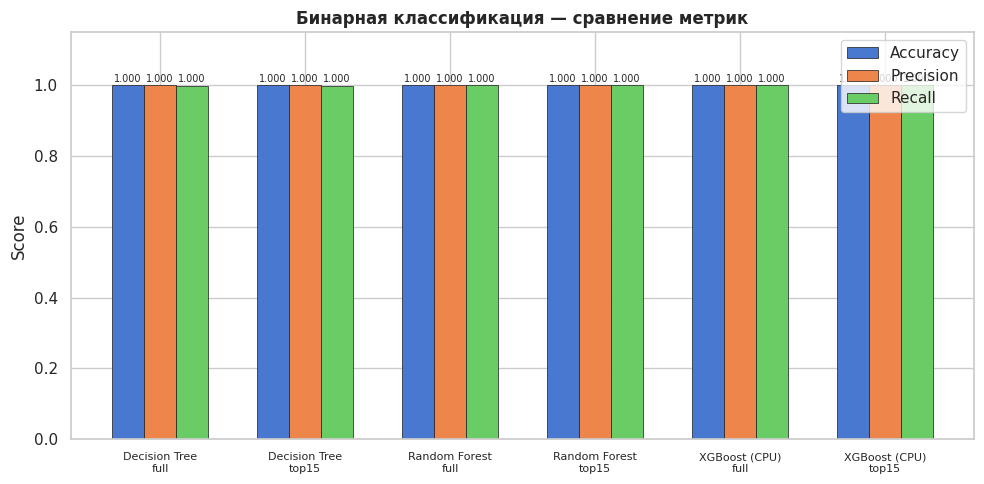

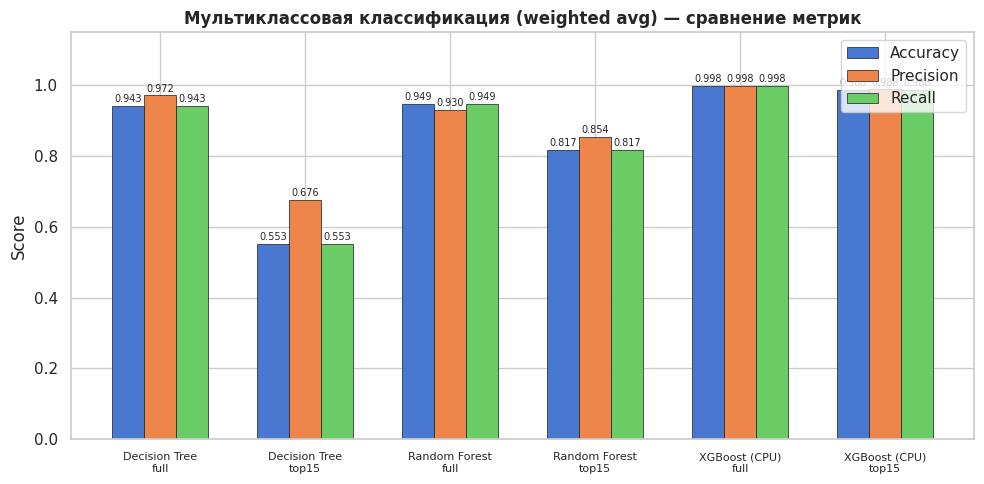

In [41]:
plot_metrics_comparison(
    df_binary,
    task_label="Бинарная классификация"
)

plot_metrics_comparison(
    df_multiclass,
    task_label="Мультиклассовая классификация (weighted avg)"
)

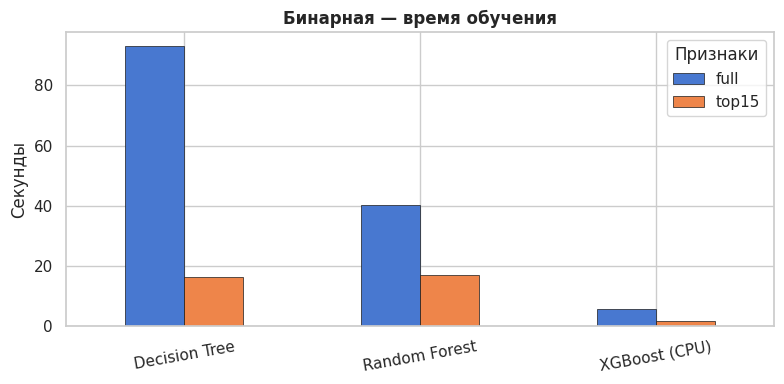

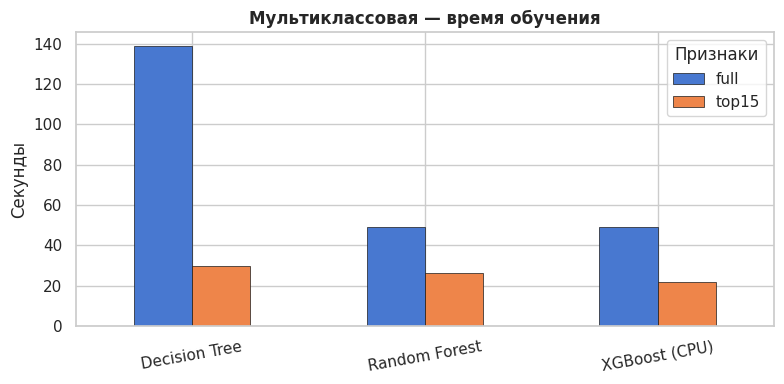

In [42]:
plot_train_time_comparison(
    df_binary,
    task_label="Бинарная"
)

plot_train_time_comparison(
    df_multiclass,
    task_label="Мультиклассовая"
)

## 7. Матрицы ошибок

Генерируются **автоматически** для каждого алгоритма × каждого режима признаков.

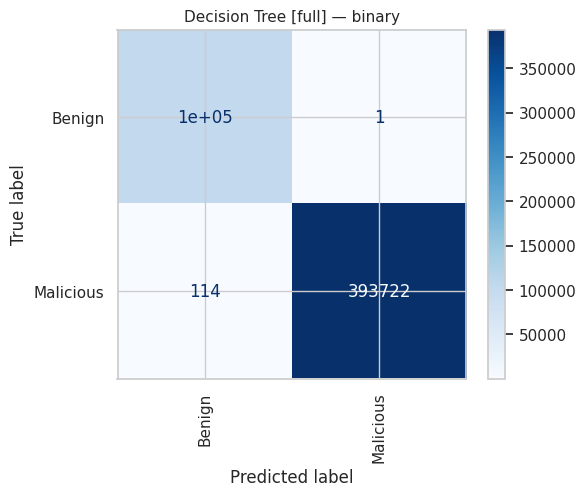

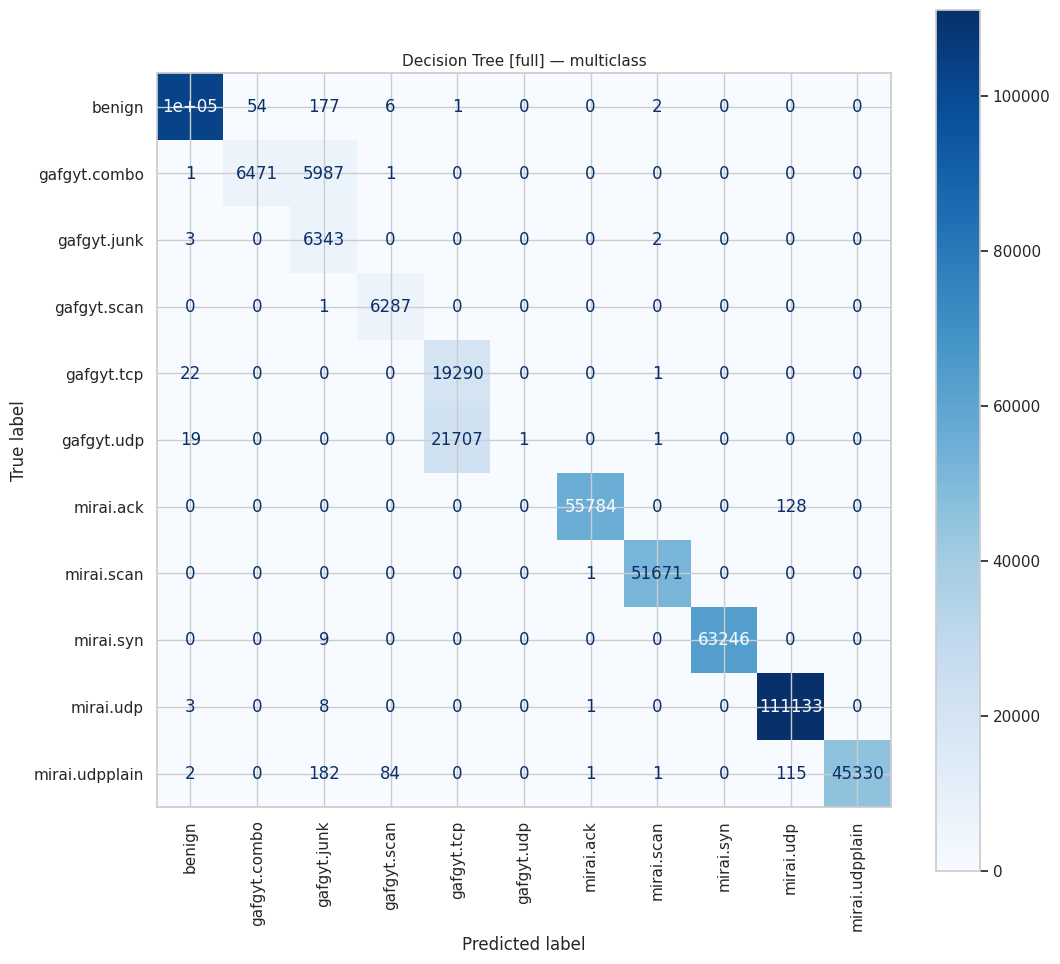

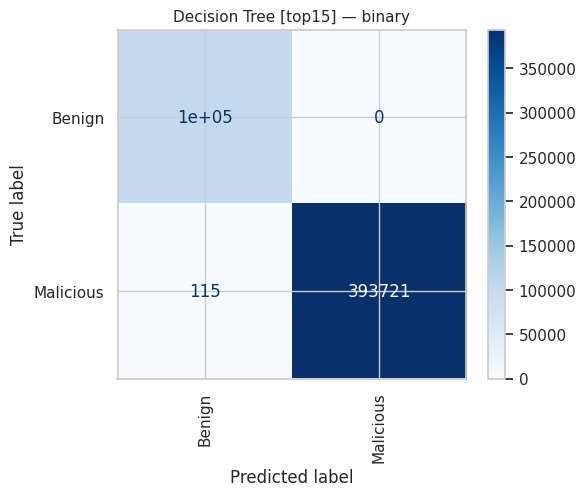

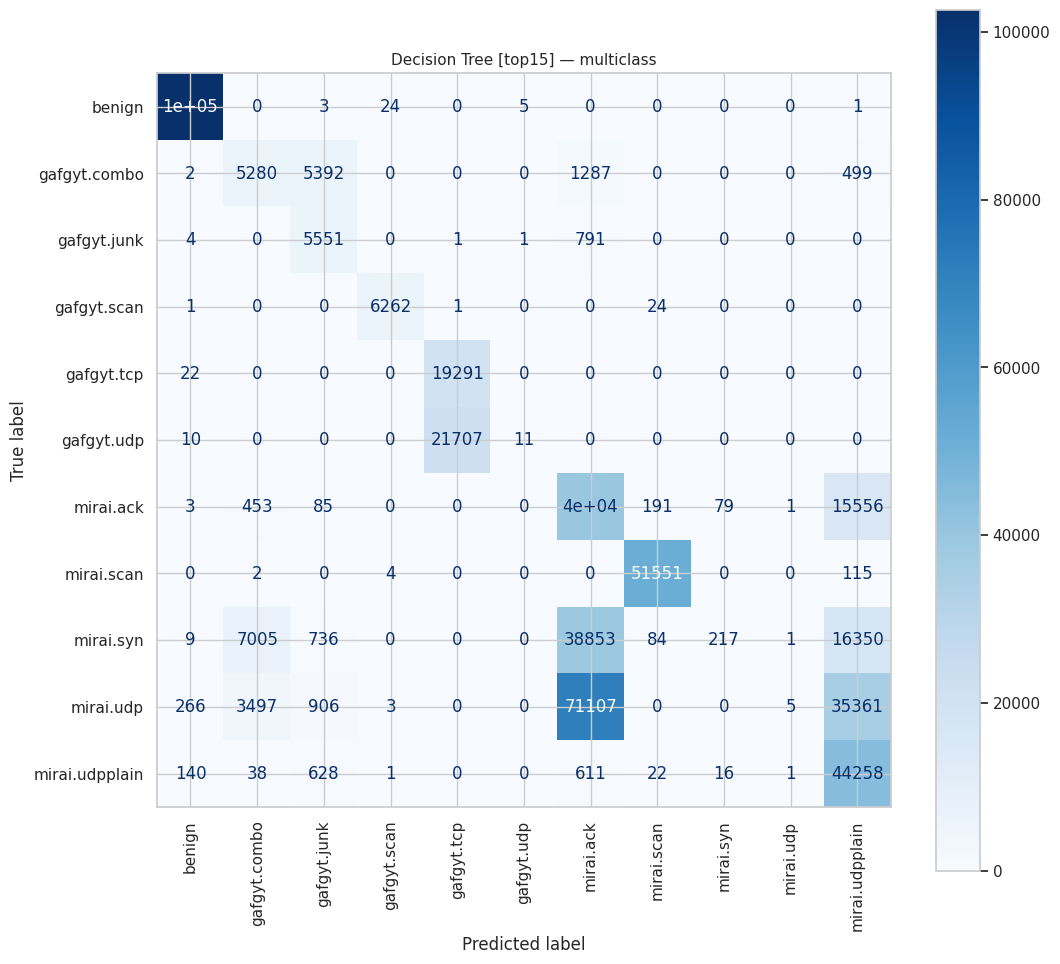

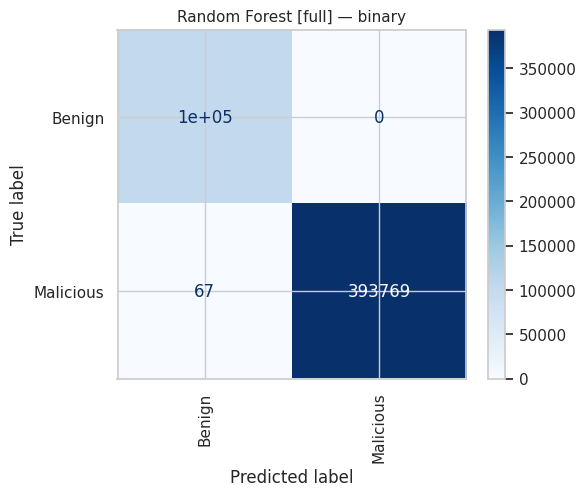

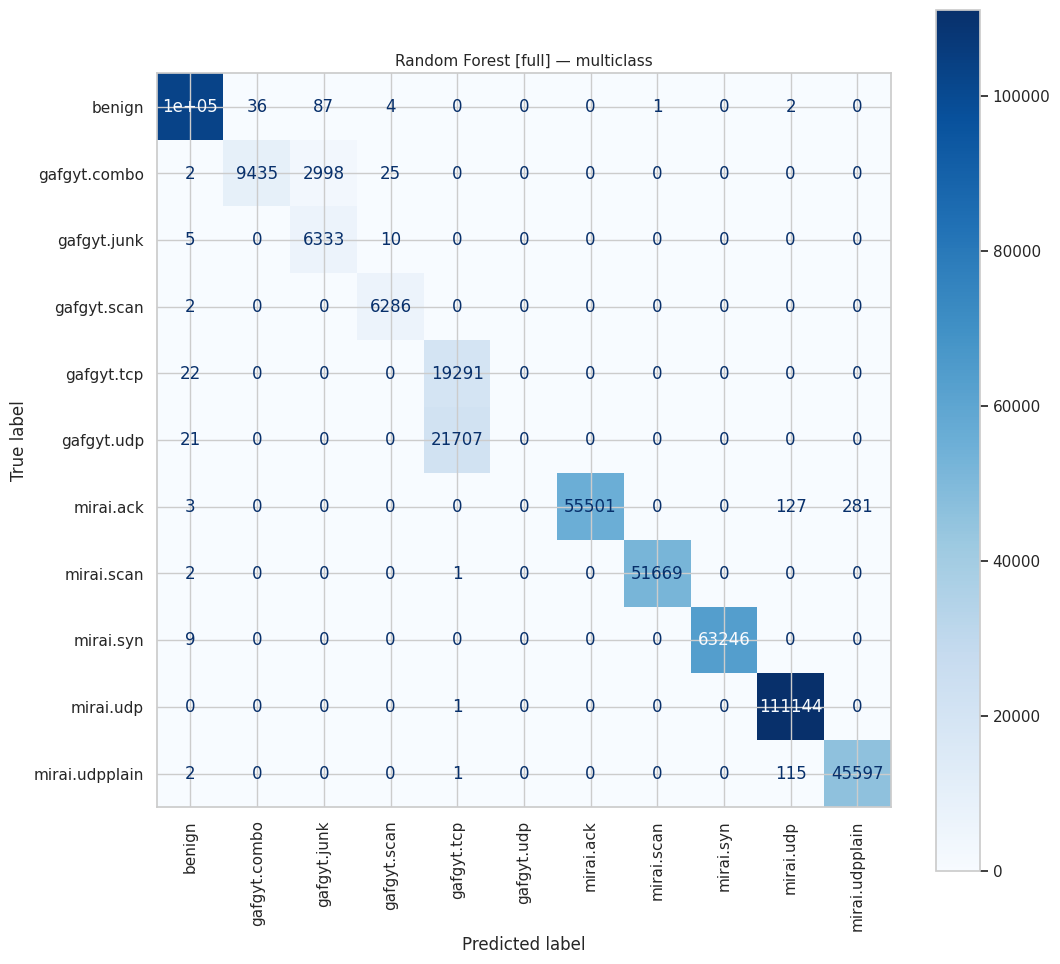

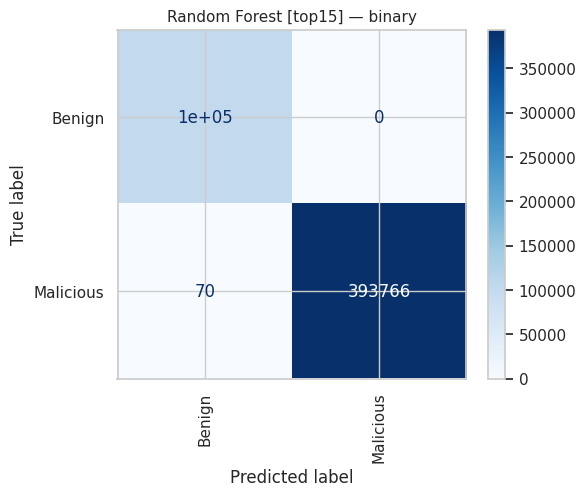

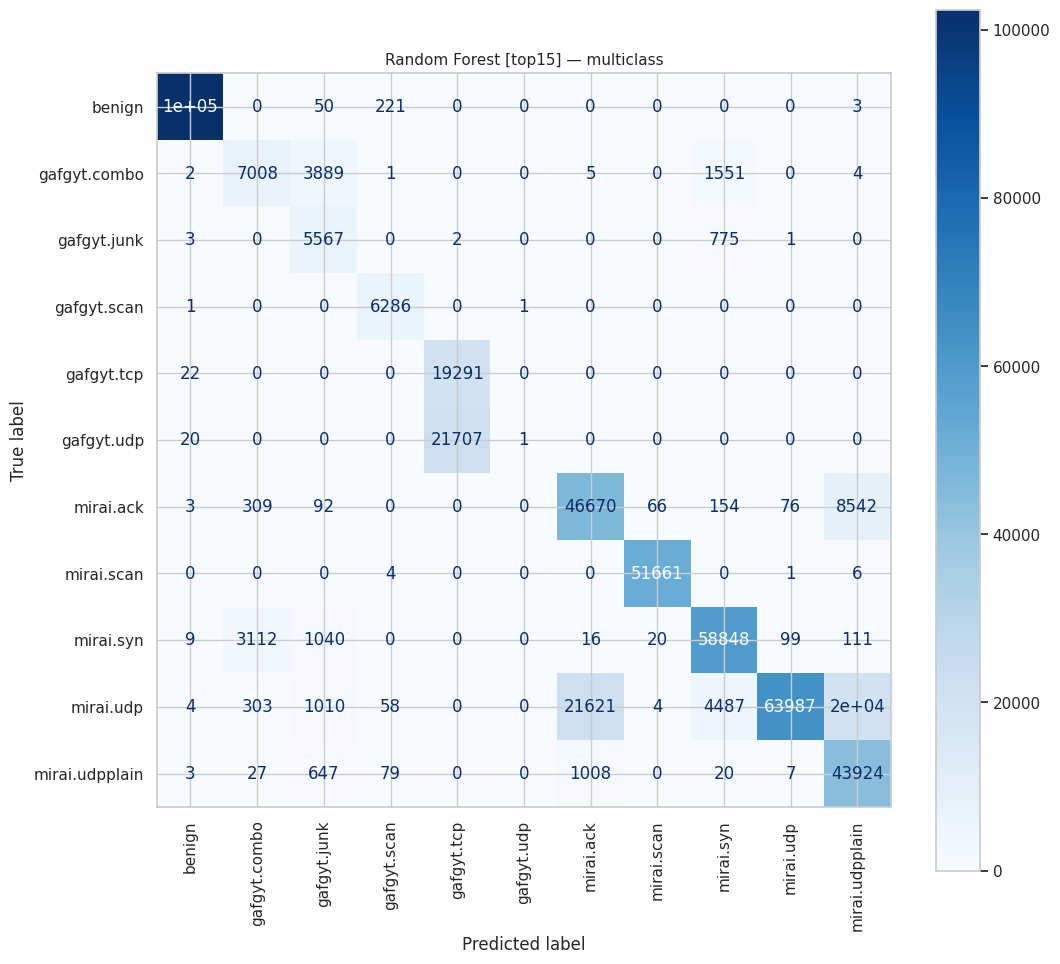

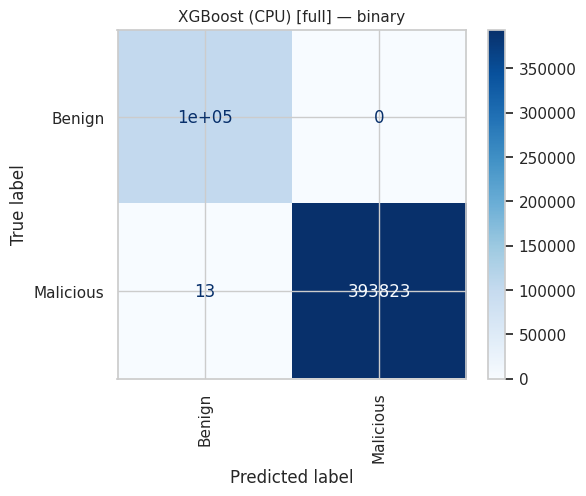

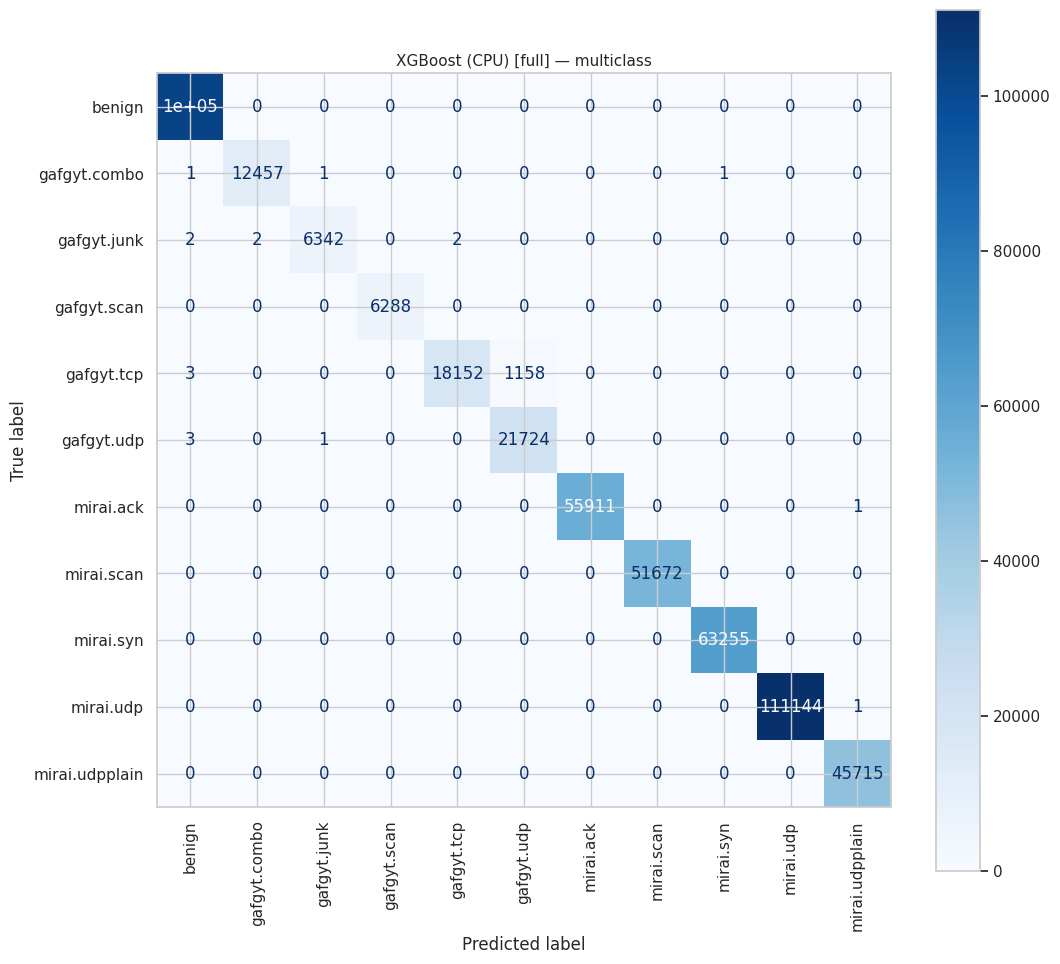

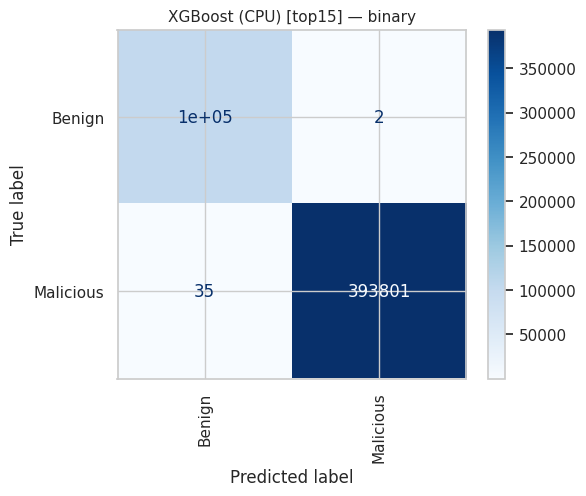

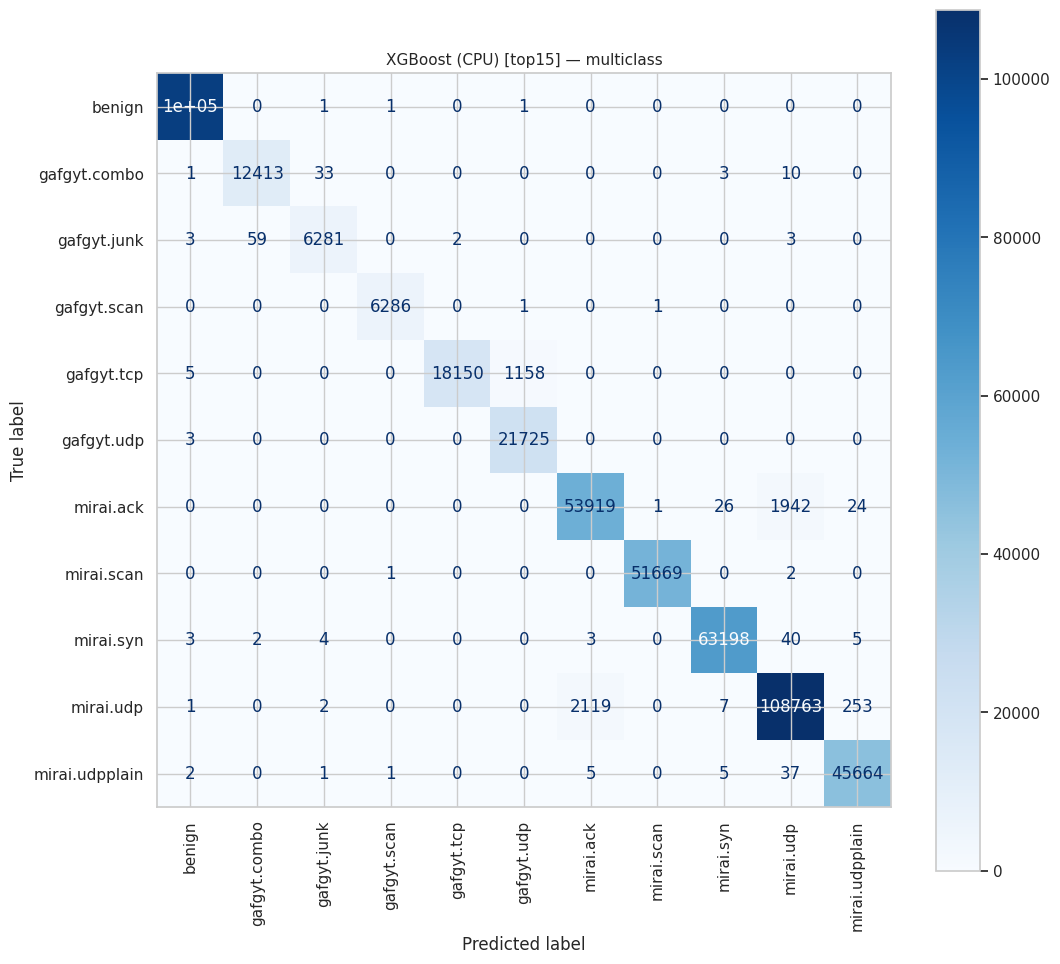

In [43]:
# Получаем тестовые метки из DATASETS
y_test_by_task = {
    task: list(DATASETS.values())[0][task][3]   # y_test — 4-й элемент кортежа
    for task in ["binary", "multiclass"]
}

for algo_name, modes in all_results.items():
    for feature_mode, tasks in modes.items():
        for task, res in tasks.items():

            plot_confusion_matrix(
                y_true      = y_test_by_task[task],
                y_pred      = res["y_pred"],
                class_names = CLASS_NAMES[task],
                title       = f"{algo_name} [{feature_mode}] — {task}"
            )

## 8. Важность признаков

Отображается для всех алгоритмов, у которых есть `feature_importances_`.  
Строится только для режима **full features** (исходные признаки), чтобы сохранить интерпретируемость.

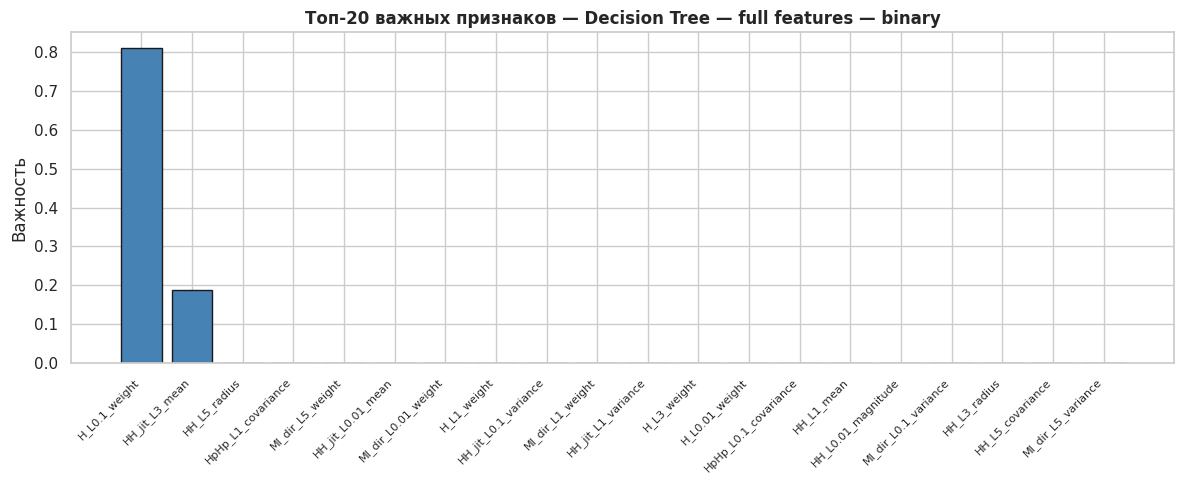

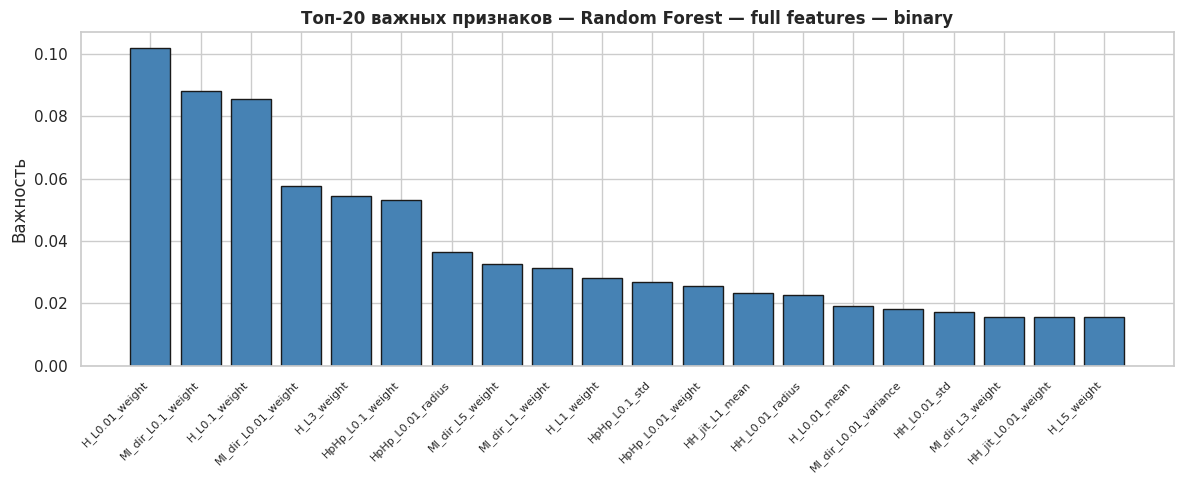

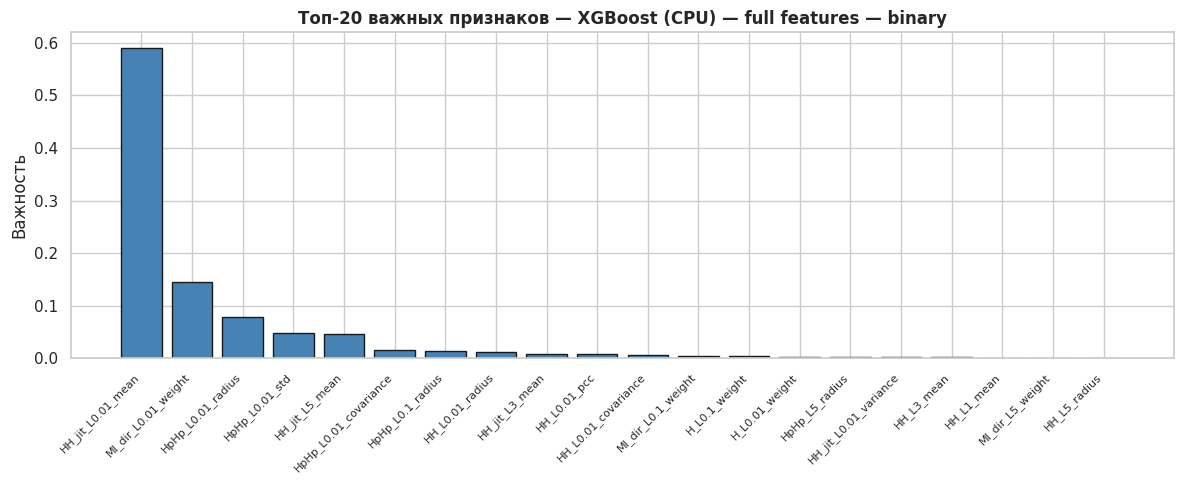

In [44]:
for algo_name, modes in all_results.items():
    # Берём модель, обученную на полных признаках, для бинарной задачи
    trained_model = modes.get("full", {}).get("binary", {}).get("model")

    if trained_model is None:
        continue

    plot_feature_importance(
        model        = trained_model,
        feature_names = FEATURE_COLS,
        title        = f"{algo_name} — full features — binary",
        top_n        = 20,
    )

## 9. Финальный отчёт

In [48]:
print("=" * 72)
print("  ФИНАЛЬНЫЙ ОТЧЁТ")
print("=" * 72)
print(f"  Датасет        : {SAMPLE_FRACTION*100:.0f}% от исходного ({sampled_rows:,} строк)")
print(f"  Train/Test     : {(1-TEST_SIZE)*100:.0f}% / {TEST_SIZE*100:.0f}%")
print(f"  Топ-признаков  : {N_TOP_FEATURES} (по корреляции с binary target)")
print(f"  Топ-признаки   : {TOP_FEATURES}")
print(f"  Алгоритмов     : {len(list(MODELS_run.keys()))}: {', '.join(MODELS_run.keys())}")

print("\nБИНАРНАЯ КЛАССИФИКАЦИЯ")
print(df_binary.to_string(index=False, float_format="{:.4f}".format))

print("\nМУЛЬТИКЛАССОВАЯ КЛАССИФИКАЦИЯ")
print(df_multiclass.to_string(index=False, float_format="{:.4f}".format))

print("\nУскорение обучения: full vs top признаков (бинарная задача)")
pca_mode = f"top{N_TOP_FEATURES}"
for algo_name in list(MODELS_run.keys()):
    row_full = df_binary[(df_binary["Алгоритм"]==algo_name) & (df_binary["Признаки"]=="full")]
    row_pca  = df_binary[(df_binary["Алгоритм"]==algo_name) & (df_binary["Признаки"]==pca_mode)]
    if row_full.empty or row_pca.empty:
        continue
    t_full  = row_full["Train time (s)"].values[0]
    t_pca   = row_pca["Train time (s)"].values[0]
    speedup = t_full / t_pca if t_pca > 0 else float("inf")
    delta_acc = (row_pca["Accuracy"].values[0] - row_full["Accuracy"].values[0]) * 100
    sign      = "+" if delta_acc >= 0 else ""
    print(f"  {algo_name:<12}: full {t_full:6.2f}с → top {t_pca:6.2f}с  "
          f"(x{speedup:.1f} быстрее)  ΔAccuracy={sign}{delta_acc:.2f}")
    
print("\nУскорение обучения: full vs top признаков (мультиклассовая задача)")
pca_mode = f"top{N_TOP_FEATURES}"
for algo_name in list(MODELS_run.keys()):
    row_full = df_multiclass[(df_multiclass["Алгоритм"]==algo_name) & (df_multiclass["Признаки"]=="full")]
    row_pca  = df_multiclass[(df_multiclass["Алгоритм"]==algo_name) & (df_multiclass["Признаки"]==pca_mode)]
    if row_full.empty or row_pca.empty:
        continue
    t_full  = row_full["Train time (s)"].values[0]
    t_pca   = row_pca["Train time (s)"].values[0]
    speedup = t_full / t_pca if t_pca > 0 else float("inf")
    delta_acc = (row_pca["Accuracy"].values[0] - row_full["Accuracy"].values[0]) * 100
    sign      = "+" if delta_acc >= 0 else ""
    print(f"  {algo_name:<12}: full {t_full:6.2f}с → top {t_pca:6.2f}с  "
          f"(x{speedup:.1f} быстрее)  ΔAccuracy={sign}{delta_acc:.2f}")

  ФИНАЛЬНЫЙ ОТЧЁТ
  Датасет        : 100% от исходного (2,482,676 строк)
  Train/Test     : 80% / 20%
  Топ-признаков  : 15 (по корреляции с binary target)
  Топ-признаки   : ['MI_dir_L0.1_weight', 'H_L0.1_weight', 'MI_dir_L1_weight', 'H_L1_weight', 'MI_dir_L3_weight', 'H_L3_weight', 'MI_dir_L5_weight', 'H_L5_weight', 'MI_dir_L0.01_weight', 'H_L0.01_weight', 'HH_L0.01_std', 'HH_jit_L0.01_mean', 'HH_jit_L0.1_mean', 'HH_jit_L1_mean', 'HH_jit_L5_mean']
  Алгоритмов     : 3: Decision Tree, Random Forest, XGBoost (CPU)

БИНАРНАЯ КЛАССИФИКАЦИЯ
     Алгоритм Признаки  Accuracy  Precision  Recall  Train time (s)
Decision Tree     full    0.9998     1.0000  0.9997         92.9256
Decision Tree    top15    0.9998     1.0000  0.9997         16.3238
Random Forest     full    0.9999     1.0000  0.9998         40.0876
Random Forest    top15    0.9999     1.0000  0.9998         16.9045
XGBoost (CPU)     full    1.0000     1.0000  1.0000          5.6993
XGBoost (CPU)    top15    0.9999     1.0000  0.9

## 10. График: время обучения vs размер датасета

Визуализирует зависимость времени обучения от доли используемого датасета для каждого алгоритма (full features и top-15 по корреляции), отдельно для бинарной и мультиклассовой задач.

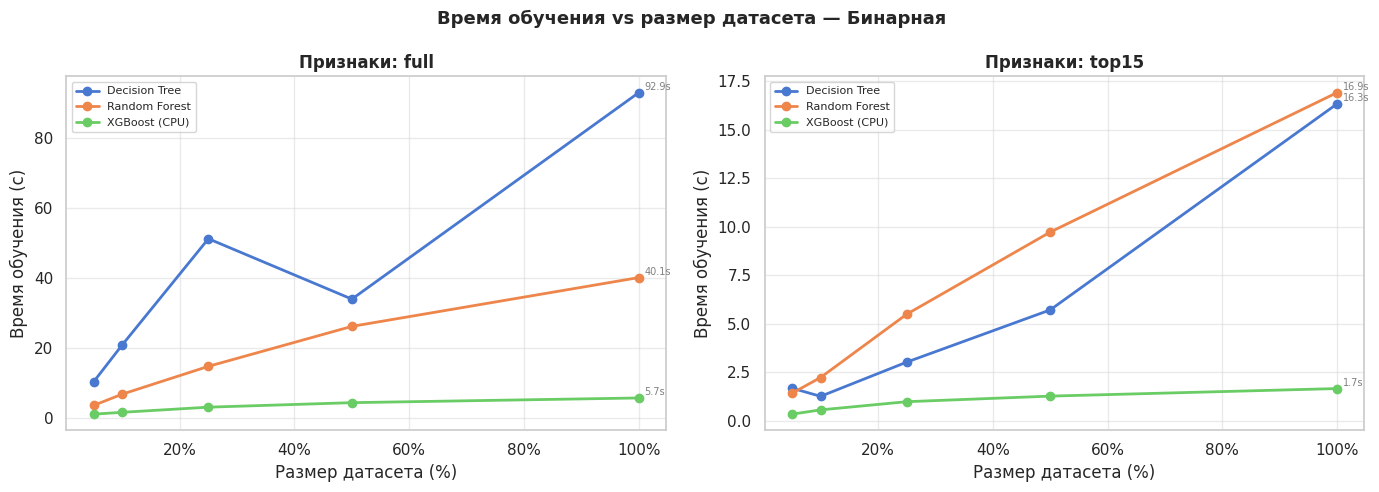

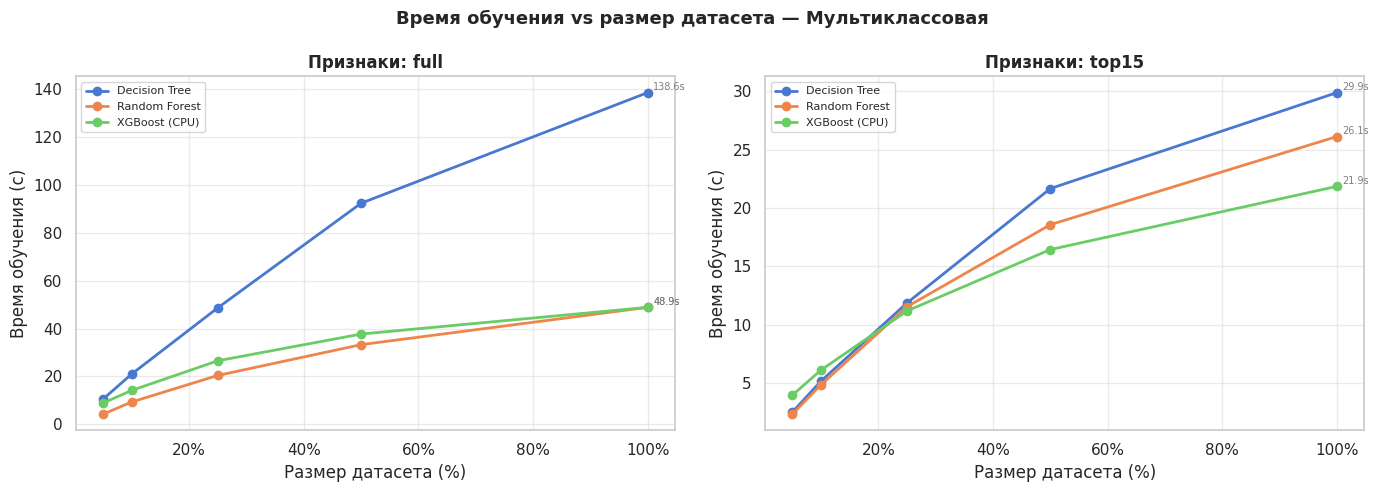


Время обучения (сек) по прогонам (бинарная задача, все признаки)
Алгоритм               |     5% |    10% |    25% |    50% |   100%
----------------------------------------------------------------------
Decision Tree          |  10.31 |  20.89 |  51.18 |  33.93 |  92.93
Random Forest          |   3.57 |   6.79 |  14.73 |  26.15 |  40.09
XGBoost (CPU)          |   1.07 |   1.60 |   3.07 |   4.36 |   5.70


In [49]:
# ╔══════════════════════════════════════════════════════════════╗
# ║        ВРЕМЯ ОБУЧЕНИЯ vs РАЗМЕР ДАТАСЕТА                    ║
# ╚══════════════════════════════════════════════════════════════╝

import matplotlib.ticker as mticker

# Собираем данные из scaling_results
# scaling_results[fraction][algo_name][feature_mode][task] → result_dict

tasks_to_plot = ["binary", "multiclass"]
task_labels   = {"binary": "Бинарная", "multiclass": "Мультиклассовая"}

for task in tasks_to_plot:

    fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=False)
    fig.suptitle(
        f"Время обучения vs размер датасета — {task_labels[task]}",
        fontsize=13, fontweight="bold"
    )

    feature_modes = list(list(scaling_results.values())[0][list(MODELS_run.keys())[0]].keys())

    for ax, feature_mode in zip(axes, feature_modes):
        for algo_name in MODELS_run:
            fractions = sorted(scaling_results.keys())
            times = [
                scaling_results[frac][algo_name][feature_mode][task]["train_time"]
                for frac in fractions
            ]
            x_vals = [frac * 100 for frac in fractions]  # % датасета
            ax.plot(x_vals, times, marker="o", linewidth=2, label=algo_name)

            # Аннотация последней точки
            ax.annotate(
                f"{times[-1]:.1f}s",
                xy=(x_vals[-1], times[-1]),
                xytext=(4, 2), textcoords="offset points",
                fontsize=7, color="gray"
            )

        ax.set_title(f"Признаки: {feature_mode}", fontweight="bold")
        ax.set_xlabel("Размер датасета (%)")
        ax.set_ylabel("Время обучения (с)")
        ax.legend(fontsize=8)
        ax.xaxis.set_major_formatter(mticker.FormatStrFormatter("%.0f%%"))
        ax.grid(True, alpha=0.4)

    plt.tight_layout()
    plt.show()

# ── Сводная таблица: время обучения по всем прогонам ────────────────────
print("\nВремя обучения (сек) по прогонам (бинарная задача, все признаки)")
header_fracs = [f"{f*100:.0f}%" for f in sorted(scaling_results.keys())]
print(f"{'Алгоритм':<22} | " + " | ".join(f"{h:>6}" for h in header_fracs))
print("-" * (22 + 3 + 9 * len(header_fracs)))

for algo_name in MODELS_run:
    row_vals = []
    for frac in sorted(scaling_results.keys()):
        t = scaling_results[frac][algo_name]["full"]["binary"]["train_time"]
        row_vals.append(f"{t:6.2f}")
    print(f"{algo_name:<22} | " + " | ".join(row_vals))


## 11. Эксперимент: влияние количества ядер CPU

Фиксируем размер датасета (`CORES_SAMPLE_FRACTION`) и обучаем на разном количестве ядер из `N_JOBS_LIST`.  
**Decision Tree** не поддерживает параллелизм — измеряется один раз как baseline.  
**Random Forest** — `n_jobs`.  
**XGBoost** — `nthread`.  

Левая колонка — полные признаки (`full`), правая — топ-15 по корреляции.  
Результаты сохраняются в `cores_results`.

In [62]:
# ╔══════════════════════════════════════════════════════════════╗
# ║   ЭКСПЕРИМЕНТ: влияние количества ядер CPU на время обучения ║
# ╚══════════════════════════════════════════════════════════════╝

import psutil as _psutil
_phys_cores = _psutil.cpu_count(logical=False)
_logi_cores = _psutil.cpu_count(logical=True)
print(f"Физических ядер: {_phys_cores}  |  Логических: {_logi_cores}")

PARALLEL_MODELS_DEF = {
    "Decision Tree": {
        "constructor": lambda n_jobs, **kw: __import__(
            "sklearn.tree", fromlist=["DecisionTreeClassifier"]
        ).DecisionTreeClassifier(
            max_depth=6, min_samples_leaf=5,
            class_weight="balanced", random_state=RANDOM_STATE
        ),
        "parallel_param": "n_jobs",
    },
    "Random Forest": {
        "constructor": lambda n_jobs, **kw: __import__(
            "sklearn.ensemble", fromlist=["RandomForestClassifier"]
        ).RandomForestClassifier(
            n_estimators=100, max_depth=6, min_samples_leaf=5,
            class_weight="balanced", random_state=RANDOM_STATE, n_jobs=n_jobs
        ),
        "parallel_param": "n_jobs",
    },
    "XGBoost (CPU)": {
        "constructor": lambda n_jobs, scale_pos_weight=1, n_classes=2, task="binary", **kw: (
            __import__("xgboost", fromlist=["XGBClassifier"]).XGBClassifier(
                n_estimators=100, max_depth=6, learning_rate=0.1,
                subsample=0.8, colsample_bytree=0.8,
                scale_pos_weight=scale_pos_weight,
                tree_method="hist", device="cpu",
                eval_metric="logloss", random_state=RANDOM_STATE,
                verbosity=0, nthread=n_jobs
            ) if task == "binary" else
            __import__("xgboost", fromlist=["XGBClassifier"]).XGBClassifier(
                n_estimators=100, max_depth=6, learning_rate=0.1,
                subsample=0.8, colsample_bytree=0.8,
                objective="multi:softmax", num_class=n_classes,
                tree_method="hist", device="cpu",
                eval_metric="mlogloss", random_state=RANDOM_STATE,
                verbosity=0, nthread=n_jobs
            )
        ),
        "parallel_param": "nthread",
    },
}

# ── Подготовка данных при фиксированном CORES_SAMPLE_FRACTION ───────────
print(f"\nПодготовка данных: {CORES_SAMPLE_FRACTION*100:.0f}% датасета...")

if CORES_SAMPLE_FRACTION < 1.0:
    _df_c, _ = train_test_split(
        df, train_size=CORES_SAMPLE_FRACTION,
        random_state=RANDOM_STATE, stratify=df["label_binary"]
    )
    _df_c = _df_c.reset_index(drop=True)
else:
    _df_c = df.copy()

_fc = [c for c in _df_c.columns if c not in ("label_binary", "label_multi")]
_df_c = _df_c.drop_duplicates(subset=_fc).reset_index(drop=True)
_std = _df_c[_fc].std()
_fc  = [c for c in _fc if _std[c] != 0]
_df_c[_fc] = _df_c[_fc].fillna(0)

_yb = _df_c["label_binary"].values
_ym = _df_c["label_multi"].values
_le_c = LabelEncoder()
_ym_enc = _le_c.fit_transform(_ym)
_nc   = len(_le_c.classes_)

# ── Разбивка сырых данных (до любого fit) ───────────────────────────────
_Xraw = _df_c[_fc].values.astype(np.float32)

_idx_c = np.arange(len(_Xraw))
_idx_c_tr, _idx_c_te, _y_tr_b, _y_te_b = train_test_split(
    _idx_c, _yb,
    test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=_yb
)
_y_tr_m = _ym_enc[_idx_c_tr]
_y_te_m = _ym_enc[_idx_c_te]

_Xraw_tr = _Xraw[_idx_c_tr]
_Xraw_te = _Xraw[_idx_c_te]

# scale_pos_weight только по train
_bc_tr = pd.Series(_y_tr_b).value_counts()
_spw   = int(_bc_tr[0]) / int(_bc_tr[1])

# Масштабирование: fit на train, transform на обоих
_scaler_c = RobustScaler()
_Xr_tr_b  = _scaler_c.fit_transform(_Xraw_tr).astype(np.float32)
_Xr_te_b  = _scaler_c.transform(_Xraw_te).astype(np.float32)

# Отбор топ-N признаков по корреляции — только на train (без утечки из теста)
_corr = (
    pd.DataFrame(_Xraw_tr, columns=_fc)
    .corrwith(pd.Series(_y_tr_b.astype(float)))
    .abs()
)
_top_idx  = _corr.nlargest(N_TOP_FEATURES).index.tolist()
_top_pos  = [_fc.index(f) for f in _top_idx]
_Xt_tr_b  = _Xr_tr_b[:, _top_pos]
_Xt_te_b  = _Xr_te_b[:, _top_pos]
del _Xraw_tr, _Xraw_te, _Xraw

# Multiclass использует те же строки и тот же масштаб
_Xr_tr_m, _Xr_te_m = _Xr_tr_b, _Xr_te_b
_Xt_tr_m, _Xt_te_m = _Xt_tr_b, _Xt_te_b

_DATASETS_C = {
    # "full":              {"binary": (_Xr_tr_b, _Xr_te_b, _y_tr_b, _y_te_b),
    #                       "multiclass": (_Xr_tr_m, _Xr_te_m, _y_tr_m, _y_te_m)},
    f"top{N_TOP_FEATURES}": {"binary": (_Xt_tr_b, _Xt_te_b, _y_tr_b, _y_te_b),
                              "multiclass": (_Xt_tr_m, _Xt_te_m, _y_tr_m, _y_te_m)},
}
print(f"  Train: {len(_Xr_tr_b):,} строк  |  Test: {len(_Xr_te_b):,} строк")

# ── Основной цикл: n_jobs ─────────────────────────────────────────────────
# cores_results[n_jobs][algo_name][feature_mode][task] → train_time
cores_results = {}

for n_jobs in N_JOBS_LIST:

    label = f"all ({_logi_cores})" if n_jobs == -1 else str(n_jobs)
    print(f"\n{'='*55}")
    print(f"  Ядра: {label}")
    print(f"{'='*55}")

    cores_results[n_jobs] = {}

    for algo_name, algo_def in PARALLEL_MODELS_DEF.items():

        cores_results[n_jobs][algo_name] = {}
        is_parallel = algo_def["parallel_param"] is not None

        for feature_mode, task_data in _DATASETS_C.items():
            cores_results[n_jobs][algo_name][feature_mode] = {}

            for task, (X_tr, X_te, y_tr, y_te) in task_data.items():

                # Однопоточные модели: замеряем один раз, остальные итерации — копируем
#                 if not is_parallel:
#                     if algo_name not in _single_thread_times:
#                         _single_thread_times[algo_name] = {}
#                     if feature_mode not in _single_thread_times[algo_name]:
#                         _single_thread_times[algo_name][feature_mode] = {}

#                     if task not in _single_thread_times[algo_name][feature_mode]:
#                         model = algo_def["constructor"](n_jobs=1)
#                         m = clone(model)
#                         t0 = time.perf_counter()
#                         m.fit(X_tr, y_tr)
#                         elapsed = time.perf_counter() - t0
#                         _single_thread_times[algo_name][feature_mode][task] = elapsed
#                         print(f"  [{feature_mode}] {algo_name}/{task}: {elapsed:.3f}s (baseline, однопоточный)")

#                     cores_results[n_jobs][algo_name][feature_mode][task] = _single_thread_times[algo_name][feature_mode][task]
#                     continue

                # Параллельные модели
                if task == "binary":
                    model = algo_def["constructor"](n_jobs=n_jobs, scale_pos_weight=_spw, task=task)
                else:
                    model = algo_def["constructor"](n_jobs=n_jobs, n_classes=_nc, task=task)

                m = clone(model)
                t0 = time.perf_counter()
                m.fit(X_tr, y_tr)
                elapsed = time.perf_counter() - t0
                cores_results[n_jobs][algo_name][feature_mode][task] = elapsed
                print(f"  [{feature_mode}] {algo_name}/{task}: {elapsed:.3f}s")

gc.collect()

Физических ядер: 16  |  Логических: 32

Подготовка данных: 100% датасета...
  Train: 1,986,140 строк  |  Test: 496,536 строк

  Ядра: 1
  [top15] Decision Tree/binary: 15.632s
  [top15] Decision Tree/multiclass: 29.343s
  [top15] Random Forest/binary: 242.231s
  [top15] Random Forest/multiclass: 392.929s
  [top15] XGBoost (CPU)/binary: 10.942s
  [top15] XGBoost (CPU)/multiclass: 188.093s

  Ядра: 2
  [top15] Decision Tree/binary: 15.393s
  [top15] Decision Tree/multiclass: 29.038s
  [top15] Random Forest/binary: 126.606s
  [top15] Random Forest/multiclass: 204.959s
  [top15] XGBoost (CPU)/binary: 6.506s
  [top15] XGBoost (CPU)/multiclass: 114.718s

  Ядра: 4
  [top15] Decision Tree/binary: 16.283s
  [top15] Decision Tree/multiclass: 29.064s
  [top15] Random Forest/binary: 67.175s
  [top15] Random Forest/multiclass: 109.224s
  [top15] XGBoost (CPU)/binary: 3.863s
  [top15] XGBoost (CPU)/multiclass: 62.747s

  Ядра: 8
  [top15] Decision Tree/binary: 16.639s
  [top15] Decision Tree/multic

119

## 12. График: время обучения vs количество ядер

Ускорение параллельных алгоритмов при увеличении числа ядер.  
**Decision Tree** отображается как горизонтальная пунктирная линия (baseline, однопоточный).  
Левая колонка — полные признаки (`full`), правая — топ-15 по корреляции.

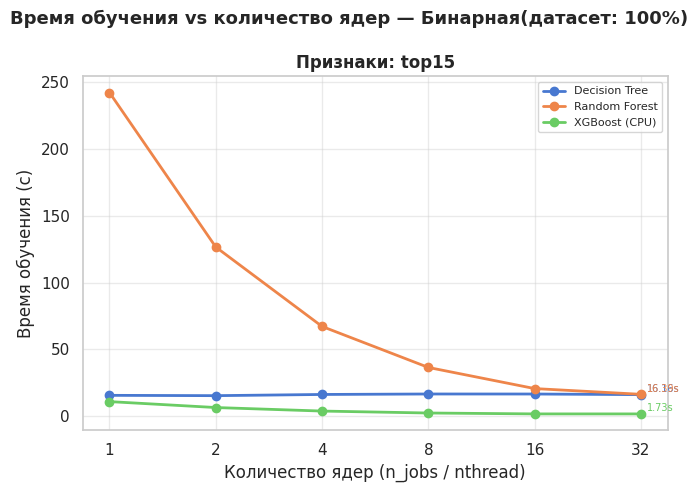

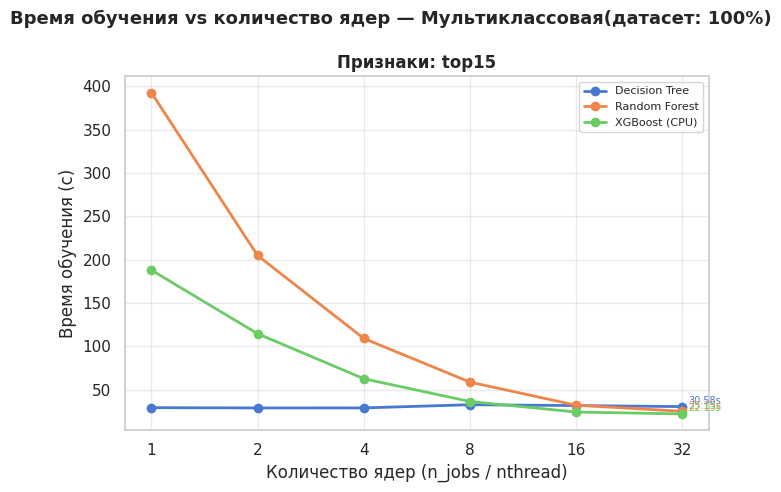


Ускорение vs 1 ядро (бинарная задача, top15)
Алгоритм                       1         2         4         8        16        32
------------------------------------------------------------------------------------
Decision Tree           x   1.00  x   1.02  x   0.96  x   0.94  x   0.94  x   0.97
Random Forest           x   1.00  x   1.91  x   3.61  x   6.64  x  11.71  x  14.78
XGBoost (CPU)           x   1.00  x   1.68  x   2.83  x   4.55  x   6.30  x   6.33


Время обучения (с) (бинарная задача, top15)
Алгоритм                       1         2         4         8        16        32
------------------------------------------------------------------------------------
Decision Tree             15.632    15.393    16.283    16.639    16.620    16.159
Random Forest            242.231   126.606    67.175    36.499    20.690    16.394
XGBoost (CPU)             10.942     6.506     3.863     2.406     1.736     1.728

Ускорение vs 1 ядро (мультикласс, top15)
Алгоритм                       1

In [63]:
# ╔══════════════════════════════════════════════════════════════╗
# ║     ГРАФИК: ВРЕМЯ ОБУЧЕНИЯ vs КОЛИЧЕСТВО ЯДЕР               ║
# ╚══════════════════════════════════════════════════════════════╝

import psutil as _psutil
_logi_cores = _psutil.cpu_count(logical=True)

def _cores_label(n):
    """Человекочитаемая метка для оси X."""
    return f"all({_logi_cores})" if n == -1 else str(n)

_parallel_algos = [a for a, d in PARALLEL_MODELS_DEF.items() if d["parallel_param"] is not None]
_single_algos   = [a for a, d in PARALLEL_MODELS_DEF.items() if d["parallel_param"] is None]

_feature_modes  = list(list(cores_results.values())[0][_parallel_algos[0]].keys())
_tasks          = ["binary", "multiclass"]
_task_labels    = {"binary": "Бинарная", "multiclass": "Мультиклассовая"}

_sorted_jobs    = sorted(cores_results.keys(), key=lambda x: _logi_cores if x == -1 else x)
_x_labels       = [_cores_label(n) for n in _sorted_jobs]
_x_pos          = list(range(len(_sorted_jobs)))

COLORS = plt.rcParams["axes.prop_cycle"].by_key()["color"]

for task in _tasks:
    fig, axes = plt.subplots(1, len(_feature_modes),
                              figsize=(7 * len(_feature_modes), 5), sharey=False)
    if len(_feature_modes) == 1:
        axes = [axes]

    fig.suptitle(
        f"Время обучения vs количество ядер — {_task_labels[task]}"
        f"(датасет: {CORES_SAMPLE_FRACTION*100:.0f}%)",
        fontsize=13, fontweight="bold"
    )

    for ax, fmode in zip(axes, _feature_modes):

        # ── Параллельные модели — линии ──────────────────────────────
        for ci, algo_name in enumerate(_parallel_algos):
            times = [cores_results[n][algo_name][fmode][task] for n in _sorted_jobs]
            ax.plot(_x_pos, times, marker="o", linewidth=2,
                    label=algo_name, color=COLORS[ci])

            # Аннотация финального значения
            ax.annotate(f"{times[-1]:.2f}s",
                        xy=(_x_pos[-1], times[-1]),
                        xytext=(4, 2), textcoords="offset points",
                        fontsize=7, color=COLORS[ci])

        # ── Однопоточные модели — горизонтальный baseline ────────────
        for ci2, algo_name in enumerate(_single_algos):
            t_ref = cores_results[_sorted_jobs[0]][algo_name][fmode][task]
            ax.axhline(t_ref, linestyle="--", linewidth=1.4,
                       color=COLORS[len(_parallel_algos) + ci2],
                       label=f"{algo_name} (однопоточный: {t_ref:.2f}s)")

        ax.set_title(f"Признаки: {fmode}", fontweight="bold")
        ax.set_xlabel("Количество ядер (n_jobs / nthread)")
        ax.set_ylabel("Время обучения (с)")
        ax.set_xticks(_x_pos)
        ax.set_xticklabels(_x_labels)
        ax.legend(fontsize=8)
        ax.grid(True, alpha=0.4)

    plt.tight_layout()
    plt.show()

MODE = "top15"

# ── Ускорение относительно 1 ядра ────────────────────────────────────────
print(f"\nУскорение vs 1 ядро (бинарная задача, {MODE})")
_base_n = _sorted_jobs[0]   # минимальное кол-во ядер (обычно 1)
header = "  ".join(f"{_cores_label(n):>8}" for n in _sorted_jobs)
print(f"{'Алгоритм':<22}  {header}")
print("-" * (22 + 2 + 10 * len(_sorted_jobs)))

for algo_name in _parallel_algos:
    t_base = cores_results[_base_n][algo_name][MODE]["binary"]
    row = "  ".join(f"x{t_base / cores_results[n][algo_name][MODE]['binary']:>7.2f}" for n in _sorted_jobs)
    print(f"{algo_name:<22}  {row}")

print()

# ── Сводная таблица: абсолютное время ────────────────────────────────────
print(f"\nВремя обучения (с) (бинарная задача, {MODE})")
print(f"{'Алгоритм':<22}  {header}")
print("-" * (22 + 2 + 10 * len(_sorted_jobs)))

for algo_name in list(PARALLEL_MODELS_DEF.keys()):
    row = "  ".join(f"{cores_results[n][algo_name][MODE]['binary']:>8.3f}" for n in _sorted_jobs)
    print(f"{algo_name:<22}  {row}")


# ── Ускорение относительно 1 ядра ────────────────────────────────────────
print(f"\nУскорение vs 1 ядро (мультикласс, {MODE})")
_base_n = _sorted_jobs[0]   # минимальное кол-во ядер (обычно 1)
header = "  ".join(f"{_cores_label(n):>8}" for n in _sorted_jobs)
print(f"{'Алгоритм':<22}  {header}")
print("-" * (22 + 2 + 10 * len(_sorted_jobs)))

for algo_name in _parallel_algos:
    t_base = cores_results[_base_n][algo_name][MODE]["multiclass"]
    row = "  ".join(f"x{t_base / cores_results[n][algo_name][MODE]['multiclass']:>7.2f}" for n in _sorted_jobs)
    print(f"{algo_name:<22}  {row}")

print()

# ── Сводная таблица: абсолютное время ────────────────────────────────────
print(f"\nВремя обучения (с) (мультикласс, {MODE})")
print(f"{'Алгоритм':<22}  {header}")
print("-" * (22 + 2 + 10 * len(_sorted_jobs)))

for algo_name in list(PARALLEL_MODELS_DEF.keys()):
    row = "  ".join(f"{cores_results[n][algo_name][MODE]['multiclass']:>8.3f}" for n in _sorted_jobs)
    print(f"{algo_name:<22}  {row}")